In [3]:
import json
import os

annotation_path = './annotations/annotations/captions_train2017.json'
image_dir = '/Users/ttanvitummapudi/Downloads/mscoco/train2017/'

with open(annotation_path, 'r') as f:
    annotations = json.load(f)

id_to_captions = {}
for annot in annotations['annotations']:
    img_id = annot['image_id']
    caption = 'startseq ' + annot['caption'].lower() + ' endseq'
    if img_id not in id_to_captions:
        id_to_captions[img_id] = []
    id_to_captions[img_id].append(caption)

def build_image_id_to_filename(image_ids):
    id_to_filename = {}
    for img_id in image_ids:
        filename = f'{img_id:012d}.jpg'  
        id_to_filename[img_id] = filename
    return id_to_filename
    
id_to_filename = build_image_id_to_filename(id_to_captions.keys())

available_files = set(os.listdir(image_dir))
valid_image_ids, valid_filenames = [], []

for img_id, filename in id_to_filename.items():
    if filename in available_files:
        valid_image_ids.append(img_id)
        valid_filenames.append(filename)

print(f" Found {len(valid_filenames)} valid image-caption pairs.")


 Found 118287 valid image-caption pairs.


In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer

all_captions = []
for cap_list in id_to_captions.values():
    all_captions.extend(cap_list)

tokenizer = Tokenizer(oov_token="<unk>")
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1
print(f" Vocabulary Size: {vocab_size}")


 Vocabulary Size: 27552


In [13]:
max_length = max(len(caption.split()) for caption in all_captions)
print(f" Max Caption Length: {max_length}")


 Max Caption Length: 51


In [15]:
available_files = set(os.listdir(image_dir))
valid_image_ids = list(id_to_captions.keys())[:5000]  
valid_filenames = [f'{img_id:012d}.jpg' for img_id in valid_image_ids if f'{img_id:012d}.jpg' in available_files]
selected_filenames = valid_filenames[:5000]


In [17]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tqdm import tqdm
import numpy as np

base_model = InceptionV3(weights='imagenet')
model_cnn = Model(base_model.input, base_model.get_layer('avg_pool').output)

def extract_features(image_dir, image_filenames):
    features = {}
    for filename in tqdm(image_filenames):
        try:
            path = os.path.join(image_dir, filename)
            image = load_img(path, target_size=(299, 299))
            image = img_to_array(image)
            image = np.expand_dims(image, axis=0)
            image = preprocess_input(image)
            feature = model_cnn.predict(image, verbose=0)
            features[filename] = feature
        except Exception as e:
            print(f" Error loading {filename}: {e}")
    return features

features = extract_features(image_dir, selected_filenames)
print(f" Extracted features for {len(features)} images")


100%|███████████████████████████████████████| 5000/5000 [07:54<00:00, 10.54it/s]

 Extracted features for 5000 images


In [19]:
print(" Sample feature keys (filenames):")
print(list(features.keys())[:5])


 Sample feature keys (filenames):
['000000203564.jpg', '000000322141.jpg', '000000016977.jpg', '000000106140.jpg', '000000571635.jpg']


In [21]:
selected_image_ids = [int(os.path.splitext(fname)[0]) for fname in features.keys()]

filtered_captions = {img_id: id_to_captions[img_id] for img_id in selected_image_ids if img_id in id_to_captions}

print(f" Filtered captions for {len(filtered_captions)} images")


 Filtered captions for 5000 images


In [23]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import os

all_captions = []
for cap_list in filtered_captions.values():
    all_captions.extend(cap_list)

max_length = max(len(caption.split()) for caption in all_captions)
print(f" Max caption length: {max_length}")

def create_sequences(tokenizer, max_length, features, captions_dict, vocab_size):
    X1, X2, y = [], [], []
    for filename in features.keys():
        img_id = int(os.path.splitext(filename)[0])
        if img_id not in captions_dict:
            continue
        photo = features[filename][0]  
        for caption in captions_dict[img_id]:
            seq = tokenizer.texts_to_sequences([caption])[0]
            for i in range(1, len(seq)):
                in_seq, out_seq = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                X1.append(photo)
                X2.append(in_seq)
                y.append(out_seq)
    return np.array(X1), np.array(X2), np.array(y)


X1, X2, y = create_sequences(tokenizer, max_length, features, filtered_captions, vocab_size)

# STEP 4: Print results
print(" Final training data:")
print("X1 (image features):", X1.shape)
print("X2 (input sequences):", X2.shape)
print("y (target words):", y.shape)


 Max caption length: 48
 Final training data:
X1 (image features): (286139, 2048)
X2 (input sequences): (286139, 48)
y (target words): (286139, 27552)


In [25]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Dropout, add

def define_model(vocab_size, max_length):
    inputs1 = Input(shape=(2048,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model


In [27]:
model = define_model(vocab_size, max_length)
model.summary()

model.fit([X1, X2], y, epochs=10, batch_size=64, verbose=1)

import keras
keras.models.save_model(model, 'caption_model.keras')


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 48)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 48, 256)   │  7,053,312 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 48, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 48)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 27552)     │  7,080,864 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,249,824 (58.17 MB)

 Trainable params: 15,249,824 (58.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
4471/4471 ━━━━━━━━━━━━━━━━━━━━ 657s 147ms/step - loss: 4.4579
Epoch 2/10
4471/4471 ━━━━━━━━━━━━━━━━━━━━ 613s 137ms/step - loss: 3.2149
Epoch 3/10
4471/4471 ━━━━━━━━━━━━━━━━━━━━ 756s 169ms/step - loss: 2.8880
Epoch 4/10
4471/4471 ━━━━━━━━━━━━━━━━━━━━ 712s 159ms/step - loss: 2.7163
Epoch 5/10
4471/4471 ━━━━━━━━━━━━━━━━━━━━ 708s 158ms/step - loss: 2.5915
Epoch 6/10
4471/4471 ━━━━━━━━━━━━━━━━━━━━ 728s 163ms/step - loss: 2.5046
Epoch 7/10
4471/4471 ━━━━━━━━━━━━━━━━━━━━ 686s 153ms/step - loss: 2.4424
Epoch 8/10
4471/4471 ━━━━━━━━━━━━━━━━━━━━ 719s 161ms/step - loss: 2.3811
Epoch 9/10
4471/4471 ━━━━━━━━━━━━━━━━━━━━ 698s 156ms/step - loss: 2.3297
Epoch 10/10
4471/4471 ━━━━━━━━━━━━━━━━━━━━ 687s 154ms/step - loss: 2.3001


In [37]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def generate_caption(model, tokenizer, photo, max_length):
    in_text = 'startseq'
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat, None)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text.split()


In [33]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import preprocess_input
import numpy as np

def extract_feature_single(image_path, model_cnn):
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    feature = model_cnn.predict(img, verbose=0)
    return feature


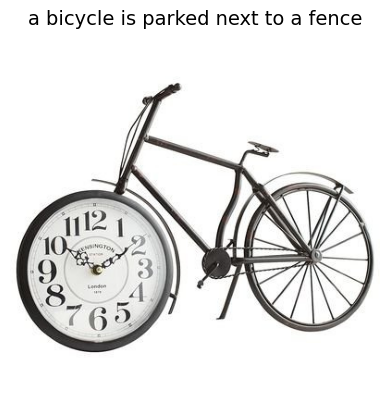

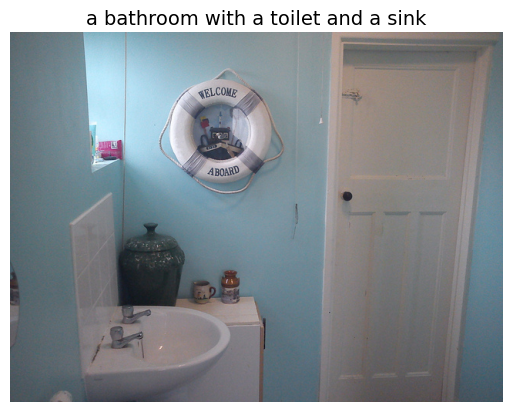

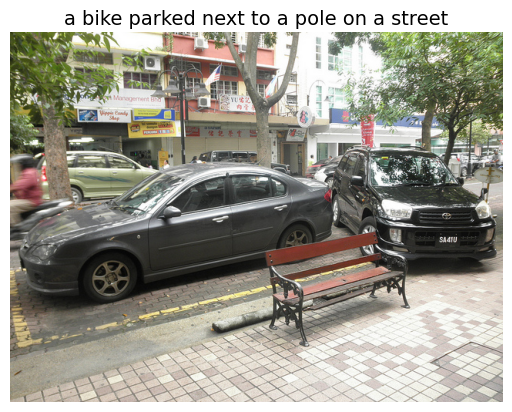

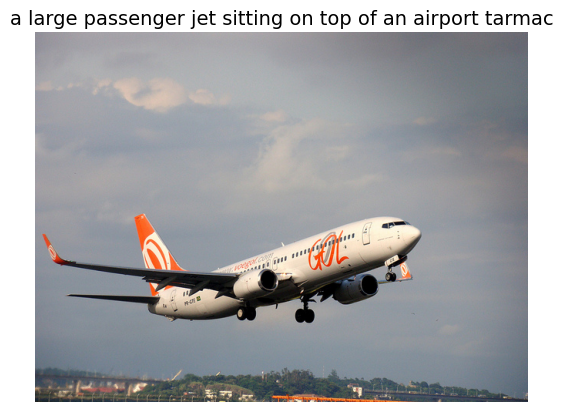

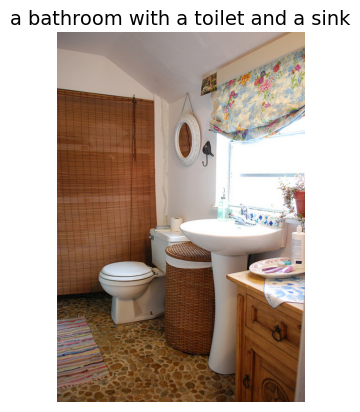

In [39]:
generate_and_show_multiple_images(
    model=model,
    tokenizer=tokenizer,
    image_dir='/Users/ttanvitummapudi/Downloads/mscoco/train2017/',
    image_filenames=selected_filenames,
    model_cnn=model_cnn,
    max_length=max_length,
    num_images=5 
)


In [41]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_bleu_on_images(model, tokenizer, image_dir, image_filenames, features, captions_dict, max_length, num_images=5):
    smoothie = SmoothingFunction().method4
    for filename in image_filenames[:num_images]:
        img_id = int(os.path.splitext(filename)[0])
        if img_id not in captions_dict:
            continue
        
        references = [[w for w in cap.split() if w not in ['startseq', 'endseq']] for cap in captions_dict[img_id]]

        image_path = os.path.join(image_dir, filename)
        feature = extract_feature_single(image_path, model_cnn)
        predicted = generate_caption(model, tokenizer, feature, max_length)
        predicted = [w for w in predicted if w not in ['startseq', 'endseq']]

        bleu1 = sentence_bleu(references, predicted, weights=(1, 0, 0, 0), smoothing_function=smoothie)
        bleu4 = sentence_bleu(references, predicted, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

        print(f" Image: {filename}")
        print(f" Prediction: {' '.join(predicted)}")
        print(f" BLEU-1: {bleu1:.4f}, BLEU-4: {bleu4:.4f}\n")


In [43]:
evaluate_bleu_on_images(
    model=model,
    tokenizer=tokenizer,
    image_dir='/Users/ttanvitummapudi/Downloads/mscoco/train2017/',
    image_filenames=selected_filenames,
    features=features,
    captions_dict=filtered_captions,
    max_length=max_length,
    num_images=5
)


 Image: 000000203564.jpg
 Prediction: a bicycle is parked next to a fence
 BLEU-1: 0.5000, BLEU-4: 0.0847

 Image: 000000322141.jpg
 Prediction: a bathroom with a toilet and a sink
 BLEU-1: 0.7722, BLEU-4: 0.2546

 Image: 000000016977.jpg
 Prediction: a bike parked next to a pole on a street
 BLEU-1: 0.6000, BLEU-4: 0.0367

 Image: 000000106140.jpg
 Prediction: a large passenger jet sitting on top of an airport tarmac
 BLEU-1: 0.3636, BLEU-4: 0.1248

 Image: 000000571635.jpg
 Prediction: a bathroom with a toilet and a sink
 BLEU-1: 1.0000, BLEU-4: 0.5623



In [45]:
pip install googletrans==4.0.0-rc1


  Using cached httpx-0.13.3-py3-none-any.whl.metadata (25 kB)
  Using cached httpcore-0.9.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached h11-0.9.0-py2.py3-none-any.whl.metadata (8.1 kB)
Using cached httpx-0.13.3-py3-none-any.whl (55 kB)
Using cached httpcore-0.9.1-py3-none-any.whl (42 kB)
Using cached h11-0.9.0-py2.py3-none-any.whl (53 kB)
  Attempting uninstall: h11
    Found existing installation: h11 0.14.0
    Uninstalling h11-0.14.0:
      Successfully uninstalled h11-0.14.0
  Attempting uninstall: httpcore
    Found existing installation: httpcore 1.0.8
    Uninstalling httpcore-1.0.8:
      Successfully uninstalled httpcore-1.0.8
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [httpx]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the 

In [27]:
from googletrans import Translator

translator = Translator()

def translate_caption(text, target_lang='hi'):
    try:
        translation = translator.translate(text, dest=target_lang)
        return translation.text
    except Exception as e:
        print(f" Translation error: {e}")
        return text


In [ ]:
# Hindi(hi), Telugu(te), Tamil(ta),French(fr), German(de),Spanish(es),Chinese(zh-cn),Arabic(ar),Japanese(ja)
image_path = '/Users/ttanvitummapudi/Downloads/mscoco/train2017/000000106140.jpg'
image = load_image_with_caption(image_path)
translated_hi = translate_caption(caption, target_lang='hi')   
translated_fr = translate_caption(caption, target_lang='fr')   
translated_te = translate_caption(caption, target_lang='te')  
translated_ch = translate_caption(caption, target_lang='zh-cn')   
translated_ja = translate_caption(caption, target_lang='ja')   
translated_ar = translate_caption(caption, target_lang='ar')  

print(" Original:", caption)
print(" Hindi:", translated_hi)
print(" French:", translated_fr)
print(" Telugu:", translated_te)
print(" Chinese:", translated_ch)
print(" Japanese:", translated_ja)
print(" Arabic:", translated_ar)


In [67]:
pip install gTTS playsound


  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'playsound' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'playsound'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for playsound: filename=playsound-1.3.0-py3-none-any.whl size=7070 sha256=18b51f88708f60a995827f9b8351907e4d14b0ffe9afec4952b088193e93c8bc
  Stored in directory: /Users/ttanvitummapudi/Library/Caches/pip/wheels/cf/42/ff/7c587bae55eec67b909ca316b250d9b4daedbf272a3cbeb907
Successfully built playsound
Note: you may need to restart the kernel to use updated packages.


In [79]:
from gtts import gTTS
import os
import uuid

def speak_translated_caption(text, lang='hi'):
    try:
        tts = gTTS(text=text, lang=lang)
        filename = f"tts_{lang}_{uuid.uuid4().hex}.mp3"
        tts.save(filename)
        print(f" Saved {lang.upper()} audio: {filename}")
        return filename
    except Exception as e:
        print(f" Error in {lang.upper()} TTS: {e}")
        return None

languages = {
    "Hindi": "hi",
    "French": "fr",
    "Telugu": "te",
    "Japanese": "ja",
    "Arabic": "ar"
}

caption_text = "A man is riding a bicycle on the street"

translations = {
    "Hindi": "एक आदमी सड़क पर साइकिल चला रहा है",
    "French": "Un homme fait du vélo dans la rue",
    "Telugu": "ఒక వ్యక్తి వీధిలో సైకిల్ తొక్కుతున్నాడు",
    "Japanese": "男が路上で自転車に乗っています",
    "Arabic": "رجل يركب دراجة في الشارع"
}

saved_files = {}
for lang_name, lang_code in languages.items():
    text = translations[lang_name]
    file = speak_translated_caption(text, lang=lang_code)
    if file:
        saved_files[lang_name] = file


 Saved HI audio: tts_hi_1790c9b5d0294db3a5817a6980528bd4.mp3
 Saved FR audio: tts_fr_47892f80caa54ba6ab52e14e325338b3.mp3
 Saved TE audio: tts_te_e5a3304d2b9f420c9e6ea7c758b7a3ee.mp3
 Saved JA audio: tts_ja_e449f97bd5f5434eaf00fcf9b06b6d03.mp3
 Saved AR audio: tts_ar_cc847c7a73304cd19d459bd0c89c24de.mp3


In [87]:
from IPython.display import Audio, display, HTML

for lang in ["Hindi", "French", "Telugu", "Arabic"]:
    print(f" {lang} Caption:")
    display(Audio(saved_files[lang], autoplay=True))


 Hindi Caption:


 French Caption:


 Telugu Caption:


 Arabic Caption:


In [89]:
pip install transformers accelerate torch torchvision


Note: you may need to restart the kernel to use updated packages.


In [1]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from PIL import Image
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = Blip2Processor.from_pretrained("Salesforce/blip2-flan-t5-xl", use_fast=False, legacy=True)
model_blip = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-flan-t5-xl").to(device)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [19]:
def load_image_with_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    
    # Show image
    plt.imshow(image)
    plt.axis("off")
    plt.title(" Loaded Image")
    plt.show()
    
    # Generate caption
    prompt = "Describe this image"
    inputs = processor(image, prompt, return_tensors="pt").to(device)
    output = model_blip.generate(**inputs, max_new_tokens=100)
    caption = processor.decode(output[0], skip_special_tokens=True)
    
    print(f"\n Caption: {caption}\n")
    return image


In [21]:
def ask_blip_question(image, question):
    inputs = processor(image, question, return_tensors="pt").to(device)
    output = model_blip.generate(**inputs, max_new_tokens=50)
    answer = processor.decode(output[0], skip_special_tokens=True)
    return answer


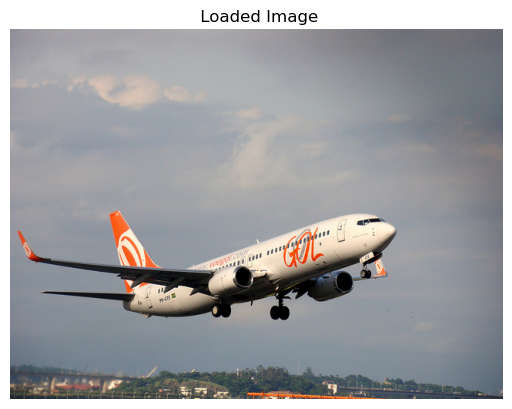


 Caption: as a plane taking off



 Enter your question (or type 'exit' to stop):  Explain image


 Answer: is a plane taking off



 Enter your question (or type 'exit' to stop):  what is plane type or size


 Answer: of the airplane



...

 Enter your question (or type 'exit' to stop):  airplane type


 Answer: is a jet



 Enter your question (or type 'exit' to stop):  airplane number


 Answer: jj aeo flt flt flt flt flt flt flt flt flt flt fl



 Enter your question (or type 'exit' to stop):  exit


In [23]:
image_path = '/Users/ttanvitummapudi/Downloads/mscoco/train2017/000000106140.jpg'
image = load_image_with_caption(image_path)

while True:
    user_question = input(" Enter your question (or type 'exit' to stop): ")
    if user_question.lower() in ['exit', 'quit']:
        break
    answer = ask_blip_question(image, user_question)
    print(f" Answer: {answer}\n")
